# BERTopic Pipeline Comparison
This notebook analyzes and compares the results of different BERTopic pipeline outputs using exported metrics and topic information from the `Outputs` directory.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, and any other libraries needed for data analysis and visualization.

In [25]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
display_available = False
try:
    from IPython.display import display
    display_available = True
except ImportError:
    pass

## 2. Load Pipeline Output Tables
Read the relevant files from each BERTopic pipeline output directory for comparison.

In [26]:
# Define paths to topic_info.csv and row_topic_assignments for each BERTopic pipeline
base_dir_candidates = ['Outputs', 'Code/Outputs']
base_dir = next((path for path in base_dir_candidates if os.path.exists(path)), None)
if base_dir is None:
    raise FileNotFoundError('Could not find Outputs folder. Checked: Outputs and Code/Outputs')
print(f"Using base_dir: {base_dir}")

pipeline_dirs = {
    'Finnhub_BERTopic': 'Finnhub_BERTopic/20260517_163614',
    'eodhd_sample_BERTopic': 'eodhd_sample_BERTopic/20260518_101343',
    'eodhd_BERTopic_all-MiniLM-L6-v2': 'eodhd_BERTopic_all-MiniLM-L6-v2/20260504_185555',
    'eodhd_BERTopic_FinBert': 'eodhd_BERTopic_FinBert/20260504_230615',
    'eodhd_BERTopic_FinLang': 'eodhd_BERTopic_FinLang/20260505_023635',
}

topic_info = {}
row_assignments = {}
for name, rel_dir in pipeline_dirs.items():
    topic_info_path = os.path.join(base_dir, rel_dir, 'tables', 'topic_info.csv')
    row_assign_path = os.path.join(base_dir, rel_dir, 'row_level', 'row_topic_assignments_all.csv')
    # Fallback for Finnhub_BERTopic which uses train split only
    if not os.path.exists(row_assign_path):
        row_assign_path = os.path.join(base_dir, rel_dir, 'row_level', 'row_topic_assignments_train.csv')
    if os.path.exists(topic_info_path):
        topic_info[name] = pd.read_csv(topic_info_path)
        print(f"Loaded topic_info for {name}")
    else:
        print(f"topic_info.csv not found for {name}")
    if os.path.exists(row_assign_path):
        row_assignments[name] = pd.read_csv(row_assign_path)
        print(f"Loaded row_topic_assignments for {name}")
    else:
        print(f"row_topic_assignments not found for {name}")

Using base_dir: Outputs
Loaded topic_info for Finnhub_BERTopic
Loaded row_topic_assignments for Finnhub_BERTopic
Loaded topic_info for eodhd_sample_BERTopic
Loaded row_topic_assignments for eodhd_sample_BERTopic
Loaded topic_info for eodhd_BERTopic_all-MiniLM-L6-v2
Loaded row_topic_assignments for eodhd_BERTopic_all-MiniLM-L6-v2
Loaded topic_info for eodhd_BERTopic_FinBert
Loaded row_topic_assignments for eodhd_BERTopic_FinBert
Loaded topic_info for eodhd_BERTopic_FinLang
Loaded row_topic_assignments for eodhd_BERTopic_FinLang
Loaded row_topic_assignments for eodhd_BERTopic_FinBert
Loaded topic_info for eodhd_BERTopic_FinLang
Loaded row_topic_assignments for eodhd_BERTopic_FinLang


## 3. Compare Topic Information
Aggregate and compare the number of topics and topic sizes from all BERTopic pipelines.

## 3a. Compare Evaluation Metrics and Optimal Hyperparameters
Load and compare evaluation metrics (from `final_metrics.csv` or `summary_stats.csv`) and optimal hyperparameters (from `best_params_per_fold.csv`) for each BERTopic pipeline.

In [27]:
# Load evaluation metrics and optimal hyperparameters for each pipeline
metrics_files = ['final_metrics.csv', 'summary_stats.csv']
params_file = 'best_params_per_fold.csv'

metrics_data = {}
params_data = {}
for name, rel_dir in pipeline_dirs.items():
    found_metrics = False
    for metrics_file in metrics_files:
        metrics_path = os.path.join(base_dir, rel_dir, 'tables', metrics_file)
        if os.path.exists(metrics_path):
            metrics_data[name] = pd.read_csv(metrics_path)
            print(f"Loaded metrics for {name} from {metrics_file}")
            found_metrics = True
            break
    if not found_metrics:
        print(f"No metrics file found for {name}")
    params_path = os.path.join(base_dir, rel_dir, 'tables', params_file)
    if os.path.exists(params_path):
        params_data[name] = pd.read_csv(params_path)
        print(f"Loaded best params for {name}")
    else:
        print(f"No best_params_per_fold.csv found for {name}")

# Combine metrics into a summary table: one row per pipeline, columns are metric (mean ± std)
summary_rows = []
for name, df in metrics_data.items():
    # Try to handle both wide and long formats
    if 'metric' in df.columns and 'mean' in df.columns:
        # Long format: metric, mean, std
        row = {'Pipeline': name}
        for _, r in df.iterrows():
            metric_name = r['metric'] if 'metric' in r else r['Metric']
            mean = r['mean'] if 'mean' in r else r.get('Mean', None)
            std = r['std'] if 'std' in r else r.get('Std', None)
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.3f} ± {std:.3f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.3f}"
        summary_rows.append(row)
    elif 'Metric' in df.columns and 'Mean' in df.columns:
        # Alternative long format
        row = {'Pipeline': name}
        for _, r in df.iterrows():
            metric_name = r['Metric']
            mean = r['Mean']
            std = r['Std'] if 'Std' in r else None
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.3f} ± {std:.3f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.3f}"
        summary_rows.append(row)
    else:
        # Wide format: columns are metrics
        row = {'Pipeline': name}
        for col in df.columns:
            if col.lower() in ['pipeline', 'fold', 'run', 'split']: continue
            vals = df[col].dropna()
            if len(vals) > 1:
                row[col] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            elif len(vals) == 1:
                row[col] = f"{vals.iloc[0]:.3f}"
        summary_rows.append(row)

metrics_summary_df = pd.DataFrame(summary_rows)
if display_available:
    display(metrics_summary_df)
else:
    print(metrics_summary_df)

Loaded metrics for Finnhub_BERTopic from summary_stats.csv
Loaded best params for Finnhub_BERTopic
Loaded metrics for eodhd_sample_BERTopic from summary_stats.csv
Loaded best params for eodhd_sample_BERTopic
Loaded metrics for eodhd_BERTopic_all-MiniLM-L6-v2 from final_metrics.csv
Loaded best params for eodhd_BERTopic_all-MiniLM-L6-v2
Loaded metrics for eodhd_BERTopic_FinBert from final_metrics.csv
Loaded best params for eodhd_BERTopic_FinBert
Loaded metrics for eodhd_BERTopic_FinLang from final_metrics.csv
Loaded best params for eodhd_BERTopic_FinLang


,Pipeline,cv_test_mean,cv_test_std,npmi_test_mean,npmi_test_std,topic_diversity_mean,topic_diversity_std,intra_topic_similarity_mean,intra_topic_similarity_std,inter_topic_similarity_mean,...,test_topic_count_mean,test_topic_count_std,Coherence C_v,Coherence NPMI,Topic Diversity,Intra-topic Similarity,Inter-topic Similarity,Silhouette (cosine),Outlier Ratio,Topic Count
0,Finnhub_BERTopic,0.497,0.015,-0.093,0.027,0.893,0.010,0.524,0.014,0.279,...,76.889,3.018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eodhd_sample_BERTopic,0.501,0.010,-0.034,0.010,0.873,0.006,0.443,0.007,0.406,...,74.000,3.391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eodhd_BERTopic_all-MiniLM-L6-v2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.477 ± 0.008,-0.022 ± 0.008,0.832 ± 0.002,0.555 ± 0.004,0.312 ± 0.005,0.074 ± 0.006,0.589 ± 0.016,529.111 ± 17.106
3,eodhd_BERTopic_FinBert,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.469 ± 0.006,-0.033 ± 0.008,0.787 ± 0.004,0.835 ± 0.003,0.676 ± 0.005,0.076 ± 0.017,0.676 ± 0.011,378.000 ± 6.461
4,eodhd_BERTopic_FinLang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.467 ± 0.005,-0.037 ± 0.005,0.783 ± 0.004,0.604 ± 0.004,0.305 ± 0.003,0.145 ± 0.005,0.554 ± 0.006,422.000 ± 8.216


### Final Metrics (Full EODHD Embedding Models)
Compares final metrics across embedding models on the full EODHD corpus only (MiniLM, FinBert, FinLang).

In [28]:
def _extract_metrics_row(df):
    if df is None or df.empty:
        return {}
    # Long format: metric + mean/std
    if 'metric' in df.columns and 'mean' in df.columns:
        row = {}
        for _, r in df.iterrows():
            metric_name = str(r['metric'])
            mean = r.get('mean', None)
            std = r.get('std', None)
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.4f} ± {std:.4f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.4f}"
        return row
    # Alternative long format: Metric + Mean/Std
    if 'Metric' in df.columns and 'Mean' in df.columns:
        row = {}
        for _, r in df.iterrows():
            metric_name = str(r['Metric'])
            mean = r.get('Mean', None)
            std = r.get('Std', None)
            if pd.notnull(mean) and pd.notnull(std):
                row[metric_name] = f"{mean:.4f} ± {std:.4f}"
            elif pd.notnull(mean):
                row[metric_name] = f"{mean:.4f}"
        return row
    # Long format: metric + value
    if 'metric' in df.columns and 'value' in df.columns:
        row = {}
        for _, r in df.iterrows():
            metric_name = str(r['metric'])
            value = r.get('value', None)
            if pd.notnull(value):
                row[metric_name] = f"{float(value):.4f}"
        return row
    # Wide format: numeric columns with multiple rows -> mean ± std
    row = {}
    drop_cols = {c for c in df.columns if str(c).lower() in ['pipeline', 'fold', 'run', 'split', 'seed']}
    for col in df.columns:
        if col in drop_cols:
            continue
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) > 1:
            row[col] = f"{vals.mean():.4f} ± {vals.std():.4f}"
        elif len(vals) == 1:
            row[col] = f"{vals.iloc[0]:.4f}"
    return row

full_eodhd_pipelines = [p for p in pipeline_dirs.keys() if p.startswith('eodhd_BERTopic')
]
final_rows = []
for pipeline in full_eodhd_pipelines:
    df = metrics_data.get(pipeline)
    if df is None:
        continue
    metrics_row = _extract_metrics_row(df)
    metrics_row['Pipeline'] = pipeline
    metrics_row['Embedding Model'] = pipeline.replace('eodhd_BERTopic_', '')
    final_rows.append(metrics_row)

final_metrics_df = pd.DataFrame(final_rows)
if not final_metrics_df.empty:
    cols = ['Pipeline', 'Embedding Model'] + [c for c in final_metrics_df.columns if c not in ['Pipeline', 'Embedding Model']]
    final_metrics_df = final_metrics_df[cols]
    if display_available:
        display(final_metrics_df)
    else:
        print(final_metrics_df)
else:
    print('No final metrics found for full EODHD pipelines.')

,Pipeline,Embedding Model,Coherence C_v,Coherence NPMI,Topic Diversity,Intra-topic Similarity,Inter-topic Similarity,Silhouette (cosine),Outlier Ratio,Topic Count
0,eodhd_BERTopic_all-MiniLM-L6-v2,all-MiniLM-L6-v2,0.4768 ± 0.0081,-0.0219 ± 0.0084,0.8318 ± 0.0022,0.5553 ± 0.0041,0.3125 ± 0.0046,0.0736 ± 0.0062,0.5894 ± 0.0156,529.1111 ± 17.1059
1,eodhd_BERTopic_FinBert,FinBert,0.4694 ± 0.0061,-0.0328 ± 0.0077,0.7873 ± 0.0037,0.8349 ± 0.0029,0.6765 ± 0.0050,0.0759 ± 0.0169,0.6763 ± 0.0114,378.0000 ± 6.4614
2,eodhd_BERTopic_FinLang,FinLang,0.4671 ± 0.0051,-0.0368 ± 0.0051,0.7835 ± 0.0042,0.6038 ± 0.0039,0.3052 ± 0.0029,0.1452 ± 0.0046,0.5536 ± 0.0058,422.0000 ± 8.2158


In [29]:
# Show best hyperparameter settings per pipeline as a table (if available)
if params_data:
    # Try to extract the best row (e.g., lowest loss or highest score) if multiple rows exist
    best_params_rows = []
    for name, df in params_data.items():
        # If there is a 'mean_score' or 'score' column, take the best row
        if 'mean_score' in df.columns:
            best_row = df.loc[df['mean_score'].idxmax()].copy()
        elif 'score' in df.columns:
            best_row = df.loc[df['score'].idxmax()].copy()
        else:
            best_row = df.iloc[0].copy()
        best_row['Pipeline'] = name
        best_params_rows.append(best_row)
    best_params_df = pd.DataFrame(best_params_rows).set_index('Pipeline')
    if display_available:
        display(best_params_df)
    else:
        print(best_params_df)
else:
    print('No best hyperparameter settings found for any pipeline.')

,fold,n_neighbors,n_components,min_cluster_size,min_samples,ngram_range,cv_val,npmi_val,topic_diversity,intra_topic_similarity,inter_topic_similarity,n_topics,cv_val_norm,npmi_val_norm,topic_diversity_norm,intra_topic_similarity_norm,inter_topic_separation_norm,fold_score
Pipeline,,,,,,,,,,,,,,,,,,
Finnhub_BERTopic,1,90,4,8,6,"(1, 2)",0.668153,0.130951,1.000000,0.581703,0.405930,2.0,1.000000,1.000000,1.000000,0.706783,0.460942,0.833545
eodhd_sample_BERTopic,1,10,4,24,1,"(1, 2)",0.632137,0.226803,1.000000,0.331821,0.695223,2.0,0.984443,0.983857,1.000000,0.141744,1.000000,0.822009
eodhd_BERTopic_all-MiniLM-L6-v2,1,50,10,15,3,"(1, 2)",0.782197,0.067391,0.933333,0.347577,0.634666,6.0,0.839994,0.844675,0.439216,0.516568,0.841035,0.696298
eodhd_BERTopic_FinBert,1,30,10,20,1,"(1, 2)",0.838264,0.126614,0.957143,0.704772,0.846165,7.0,1.000000,0.980083,0.877551,0.313034,0.782887,0.790711
eodhd_BERTopic_FinLang,1,30,5,20,3,"(1, 2)",0.584647,-0.031591,0.955556,0.369621,0.641802,9.0,0.769561,0.836860,1.000000,0.000000,1.000000,0.721284


In [30]:
# Compare number of topics and topic sizes
topic_counts = {name: len(df) for name, df in topic_info.items()}
topic_sizes = {name: df['Count'].describe() if 'Count' in df.columns else None for name, df in topic_info.items()}
print('Number of topics per pipeline:')
print(topic_counts)
print('\nTopic size statistics:')
for name, stats in topic_sizes.items():
    print(f'--- {name} ---')
    print(stats)

Number of topics per pipeline:
{'Finnhub_BERTopic': 72, 'eodhd_sample_BERTopic': 74, 'eodhd_BERTopic_all-MiniLM-L6-v2': 549, 'eodhd_BERTopic_FinBert': 378, 'eodhd_BERTopic_FinLang': 436}

Topic size statistics:
--- Finnhub_BERTopic ---
count      72.000000
mean       49.819444
std       180.510257
min         8.000000
25%        15.750000
50%        23.000000
75%        37.250000
max      1551.000000
Name: Count, dtype: float64
--- eodhd_sample_BERTopic ---
count      74.000000
mean      133.486486
std       311.408917
min        32.000000
25%        50.000000
50%        68.000000
75%       108.000000
max      2654.000000
Name: Count, dtype: float64
--- eodhd_BERTopic_all-MiniLM-L6-v2 ---
count      549.000000
mean       100.848816
std        999.445471
min         15.000000
25%         20.000000
50%         32.000000
75%         60.000000
max      23388.000000
Name: Count, dtype: float64
--- eodhd_BERTopic_FinBert ---
count      378.000000
mean       146.470899
std       1485.060656
m

In [31]:
# Analyze topic_info for the different pipelines: topic size, top words, and topic statistics
topic_info_tables = []
for name, df in topic_info.items():
    df = df.copy()
    df['Pipeline'] = name
    topic_info_tables.append(df)
if topic_info_tables:
    all_topic_info = pd.concat(topic_info_tables, ignore_index=True)
    # Show top 5 topics by size for each pipeline
    for name in all_topic_info['Pipeline'].unique():
        print(f'\nTop 5 topics by size for {name}:')
        top_topics = all_topic_info[all_topic_info['Pipeline'] == name].sort_values('Count', ascending=False).head(5)
        if display_available:
            display(top_topics[['Topic', 'Count', 'Name']]) if 'Name' in top_topics.columns else display(top_topics[['Topic', 'Count']])
        else:
            print(top_topics[['Topic', 'Count', 'Name']] if 'Name' in top_topics.columns else top_topics[['Topic', 'Count']])
    # Show top words for a sample topic in each pipeline
    for name in all_topic_info['Pipeline'].unique():
        print(f'\nSample topic words for {name}:')
        sample_topic = all_topic_info[all_topic_info['Pipeline'] == name].iloc[0]
        if 'Words' in sample_topic:
            print(f"Topic {sample_topic['Topic']}: {sample_topic['Words']}")
        elif 'Top Words' in sample_topic:
            print(f"Topic {sample_topic['Topic']}: {sample_topic['Top Words']}")


Top 5 topics by size for Finnhub_BERTopic:


,Topic,Count,Name
0,-1,1551,-1_bank_earnings_market_2025
1,0,92,0_nvcc_series_bank_notes
2,1,87,1_japan_japanese_ufg_mitsubishi ufg
3,2,78,2_fund_commentary_2025 commentary_q2 2025
4,3,76,3_oil_oil prices_prices_iran



Top 5 topics by size for eodhd_sample_BERTopic:


,Topic,Count,Name
72,-1,2654,-1_earnings_stock_bank_growth
73,0,587,0_shifting_story_story shifting_narrative
74,1,425,1_ai_software_shifting ai_tech
75,2,339,2_earnings_q4_q3_q2
76,3,294,3_oil_iran_oil prices_prices



Top 5 topics by size for eodhd_BERTopic_all-MiniLM-L6-v2:


...


Top 5 topics by size for eodhd_BERTopic_FinBert:


,Topic,Count,Name
695,-1,28710,-1_says_market_banks_credit
696,0,2759,0_oil_rate_futures_fed
697,1,1651,1_head_appoints_names_hires
698,2,1378,2_pay_fined_settle_million
699,3,719,3_profit_beat_rises_beats



Top 5 topics by size for eodhd_BERTopic_FinLang:


,Topic,Count,Name
1073,-1,23664,-1_bank_stocks_new_says
1074,0,755,0_appoints_head_names_hires
1075,1,629,1_oil_opec_supply_oil prices
1076,2,503,2_ceo_dimon_jamie dimon_jamie
1077,3,448,3_pay_fined_settle_million



Sample topic words for Finnhub_BERTopic:

Sample topic words for eodhd_sample_BERTopic:

Sample topic words for eodhd_BERTopic_all-MiniLM-L6-v2:

Sample topic words for eodhd_BERTopic_FinBert:

Sample topic words for eodhd_BERTopic_FinLang:


## 4. Visualize Topic Counts and Sizes
Create bar plots to compare the number of topics and topic size distributions across BERTopic pipelines.

C:\Users\gianf\AppData\Local\Temp\ipykernel_22132\3666769435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(topic_counts.keys()), y=list(topic_counts.values()), palette='Blues_d')


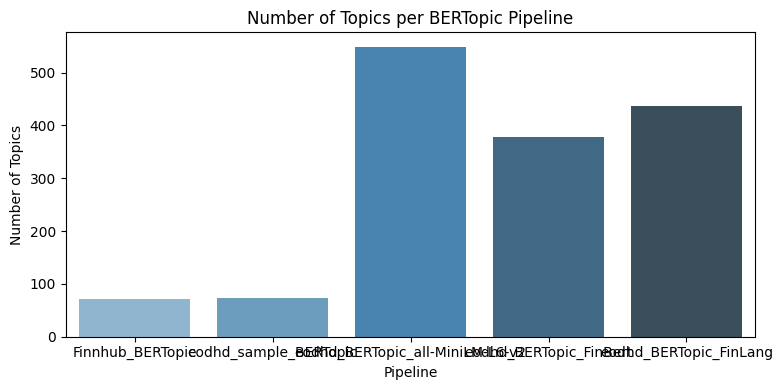

C:\Users\gianf\AppData\Local\Temp\ipykernel_22132\3666769435.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pipeline', y='Topic Size', data=sizes_df, palette='Greens_d')


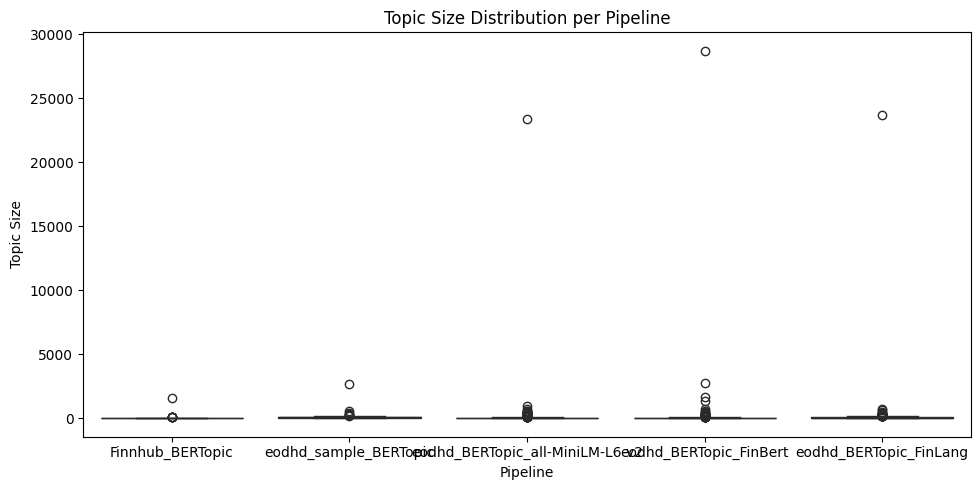

In [32]:
# Bar plot for number of topics
plt.figure(figsize=(8, 4))
sns.barplot(x=list(topic_counts.keys()), y=list(topic_counts.values()), palette='Blues_d')
plt.title('Number of Topics per BERTopic Pipeline')
plt.ylabel('Number of Topics')
plt.xlabel('Pipeline')
plt.tight_layout()
plt.show()

# Boxplot for topic sizes (if available)
plt.figure(figsize=(10, 5))
sizes_data = []
for name, df in topic_info.items():
    if 'Count' in df.columns:
        for val in df['Count']:
            sizes_data.append({'Pipeline': name, 'Topic Size': val})
if sizes_data:
    sizes_df = pd.DataFrame(sizes_data)
    sns.boxplot(x='Pipeline', y='Topic Size', data=sizes_df, palette='Greens_d')
    plt.title('Topic Size Distribution per Pipeline')
    plt.tight_layout()
    plt.show()